
# Closed-loop AO: frozen-flow atmosphere, deformable mirror, and integrator control

This notebook adds a minimal closed-loop adaptive-optics simulation.

The model chain is:

```text
frozen-flow atmospheric phase
        -> residual phase = atmosphere - DM
        -> Shack-Hartmann slope measurement
        -> least-squares actuator reconstruction
        -> integrator controller
        -> updated DM command
        -> residual RMS and Strehl evaluation
```

This is still a compact learning simulator, but it introduces the central AO concept: **the WFS does not only reconstruct a static wavefront; it drives a deformable mirror in a feedback loop.**


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))

from phase_screen import fourier_phase_screen
from reconstruction import rms
from psf_tools import strehl_ratio
from ao_closed_loop import (
    actuator_centers_on_pupil,
    gaussian_influence_functions,
    build_dm_wfs_response_matrix,
    synthesize_dm_phase,
    shifted_atmosphere,
    run_closed_loop_ao,
    gain_scan,
)


## 1. Generate a toy atmospheric phase screen

We generate a Kolmogorov/von-Kármán-like phase screen and normalize its RMS.  This keeps the experiment numerically stable and easy to interpret.


In [2]:

N = 256
D = 1.0
delta = D / N

phase0, X, Y, pupil_mask = fourier_phase_screen(
    N=N,
    delta=delta,
    diameter=D,
    r0=0.25,
    L0=10.0,
    target_rms_rad=1.0,
    seed=4,
)

print(f"Atmospheric phase RMS: {rms(phase0, pupil_mask):.4f} rad")
print(f"Uncorrected Strehl: {strehl_ratio(phase0, pupil_mask, pad_factor=4):.4f}")

Atmospheric phase RMS: 1.0000 rad
Uncorrected Strehl: 0.4551


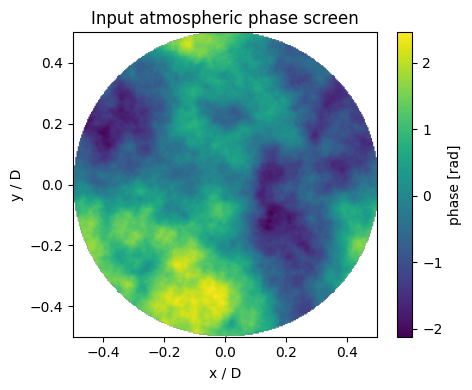

In [3]:
plt.figure(figsize=(5, 4))
plt.imshow(phase0, origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
plt.colorbar(label="phase [rad]")
plt.title("Input atmospheric phase screen")
plt.xlabel("x / D")
plt.ylabel("y / D")
plt.tight_layout()
plt.show()


## 2. Build a simple Gaussian influence-function deformable mirror

The DM is represented by a square grid of actuators inside the circular pupil.  Each actuator has a Gaussian influence function.  This is not a calibrated real DM, but it captures the basic idea that actuator commands synthesize a smooth corrective surface.


In [4]:
n_actuators_across = 7
centers, pitch = actuator_centers_on_pupil(
    diameter=D,
    n_actuators=n_actuators_across,
    include_edge=True,
)

influence_functions = gaussian_influence_functions(
    X,
    Y,
    pupil_mask,
    centers,
    pitch,
    coupling=0.45,
)

print(f"Number of active actuators: {len(centers)}")
print(f"Actuator pitch: {pitch:.3f} D")

Number of active actuators: 29
Actuator pitch: 0.167 D


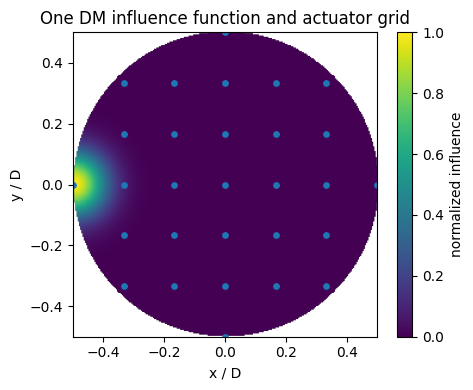

In [5]:
plt.figure(figsize=(5, 4))
plt.imshow(influence_functions[0], origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
plt.scatter(centers[:, 0], centers[:, 1], s=15)
plt.colorbar(label="normalized influence")
plt.title("One DM influence function and actuator grid")
plt.xlabel("x / D")
plt.ylabel("y / D")
plt.tight_layout()
plt.show()


## 3. DM-to-WFS response matrix

The response matrix maps actuator commands to Shack-Hartmann slope vectors.  This is the actuator-space equivalent of the modal response matrix used in earlier notebooks.


In [6]:
n_lenslets = 10
min_fill = 0.45

B_dm, wfs_centers = build_dm_wfs_response_matrix(
    influence_functions,
    pupil_mask,
    X,
    Y,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
)

print(f"DM-WFS response matrix shape: {B_dm.shape}")
print(f"Valid SH sub-apertures: {len(wfs_centers)}")
print(f"Condition number: {np.linalg.cond(B_dm):.2e}")

DM-WFS response matrix shape: (160, 29)
Valid SH sub-apertures: 80
Condition number: 2.24e+00


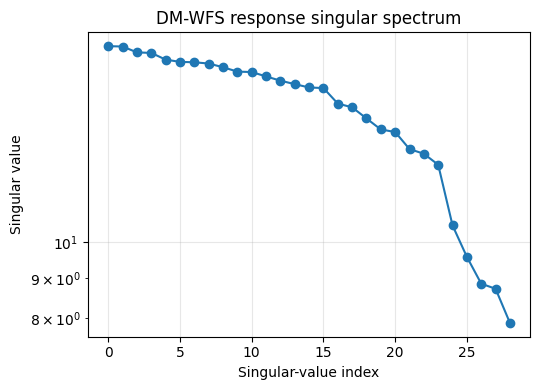

In [7]:
singular_values = np.linalg.svd(B_dm, compute_uv=False)

plt.figure(figsize=(5.5, 4))
plt.semilogy(singular_values, marker="o")
plt.xlabel("Singular-value index")
plt.ylabel("Singular value")
plt.title("DM-WFS response singular spectrum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Run the closed loop

The controller is a simple integrator:

```text
commands <- (1 - leak) commands + gain * reconstructed_delta_commands
```

A moderate gain should reduce the residual wavefront.  Too low a gain converges slowly.  Too high a gain may amplify noise or become unstable in more realistic delayed systems.


In [8]:
history = run_closed_loop_ao(
    phase0,
    pupil_mask,
    X,
    Y,
    influence_functions,
    B_dm,
    n_steps=40,
    wind_shift_per_step=(1, 0),
    gain=0.4,
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    slope_noise_std=0.01,
    rcond=1e-3,
    command_leak=0.01,
    compute_strehl=True,
    pad_factor=4,
    seed=5,
)

print(f"Initial atmospheric RMS: {history['rms_atmosphere'][0]:.4f} rad")
print(f"First-step corrected RMS: {history['rms_after'][0]:.4f} rad")
print(f"Final corrected RMS: {history['rms_after'][-1]:.4f} rad")
print(f"Final corrected Strehl: {history['strehl_after'][-1]:.4f}")

Initial atmospheric RMS: 1.0000 rad
First-step corrected RMS: 0.7292 rad
Final corrected RMS: 0.4544 rad
Final corrected Strehl: 0.8147


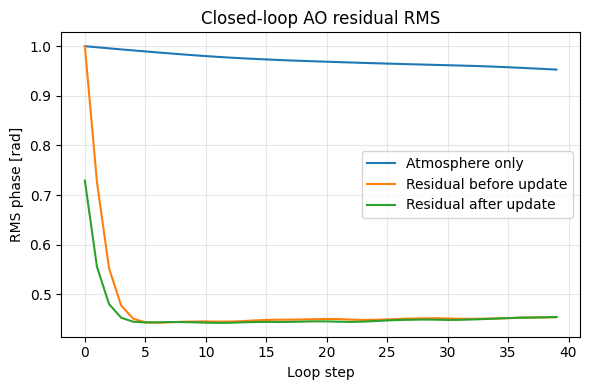

In [9]:
steps = np.arange(len(history["rms_after"]))

plt.figure(figsize=(6, 4))
plt.plot(steps, history["rms_atmosphere"], label="Atmosphere only")
plt.plot(steps, history["rms_before"], label="Residual before update")
plt.plot(steps, history["rms_after"], label="Residual after update")
plt.xlabel("Loop step")
plt.ylabel("RMS phase [rad]")
plt.title("Closed-loop AO residual RMS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

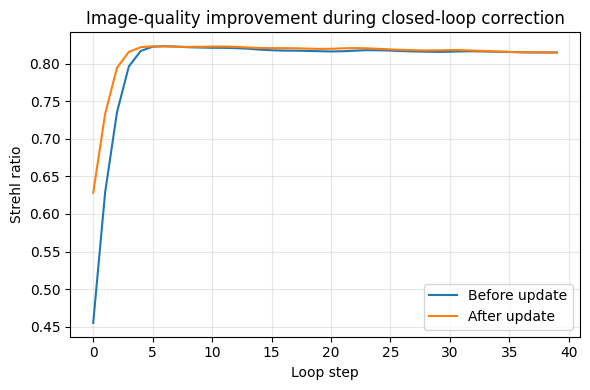

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(steps, history["strehl_before"], label="Before update")
plt.plot(steps, history["strehl_after"], label="After update")
plt.xlabel("Loop step")
plt.ylabel("Strehl ratio")
plt.title("Image-quality improvement during closed-loop correction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Visualize a corrected residual phase

The DM cannot remove all phase structure, especially if the atmospheric phase contains spatial frequencies beyond the actuator grid.  The residual is therefore a combination of fitting error, WFS noise, temporal/frozen-flow error, and numerical regularization.


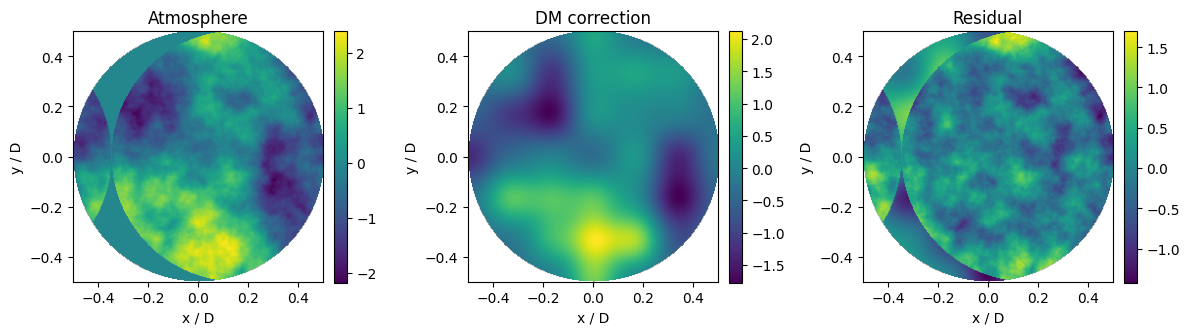

In [11]:
# Reconstruct the final command approximately by re-running a short loop without hiding internals.
# For visualization, we use the final state from the same control settings by repeating the update logic compactly.
from reconstruction import measure_slopes
from ao_closed_loop import reconstruct_dm_delta

commands = np.zeros(influence_functions.shape[0])
for k in range(40):
    atm = shifted_atmosphere(phase0, pupil_mask, shift_x_pix=k, shift_y_pix=0)
    dm = synthesize_dm_phase(commands, influence_functions, pupil_mask)
    residual = np.where(pupil_mask, atm - dm, np.nan)
    residual[pupil_mask] -= np.nanmean(residual[pupil_mask])
    _, slopes = measure_slopes(
        residual,
        pupil_mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=min_fill,
        noise_std=0.01,
        seed=100 + k,
    )
    delta_commands, *_ = reconstruct_dm_delta(slopes, B_dm, rcond=1e-3)
    commands = 0.99 * commands + 0.4 * delta_commands

atm_final = shifted_atmosphere(phase0, pupil_mask, shift_x_pix=39, shift_y_pix=0)
dm_final = synthesize_dm_phase(commands, influence_functions, pupil_mask)
res_final = np.where(pupil_mask, atm_final - dm_final, np.nan)
res_final[pupil_mask] -= np.nanmean(res_final[pupil_mask])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
for ax, img, title in zip(
    axes,
    [atm_final, dm_final, res_final],
    ["Atmosphere", "DM correction", "Residual"],
):
    im = ax.imshow(img, origin="lower", extent=[-0.5, 0.5, -0.5, 0.5])
    ax.set_title(title)
    ax.set_xlabel("x / D")
    ax.set_ylabel("y / D")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 6. Loop-gain scan

A loop-gain scan is useful because AO control is not only a reconstruction problem; it is a dynamical control problem.  In this simple zero-delay model, high gains may still work reasonably well.  In a more realistic model with frame delay, wind speed, measurement noise, and DM dynamics, the stable gain range becomes narrower.


In [12]:
gains = [0.1, 0.2, 0.4, 0.7, 1.0]
scan = gain_scan(
    gains,
    phase0,
    pupil_mask,
    X,
    Y,
    influence_functions,
    B_dm,
    n_steps=40,
    wind_shift_per_step=(1, 0),
    n_lenslets=n_lenslets,
    min_fill=min_fill,
    slope_noise_std=0.01,
    rcond=1e-3,
    command_leak=0.01,
    seed=6,
)

for gain, stats in scan.items():
    print(
        f"gain={gain:3.1f}  "
        f"median tail RMS={stats['median_tail_rms']:.4f} rad  "
        f"final RMS={stats['final_rms']:.4f} rad"
    )

gain=0.1  median tail RMS=0.4812 rad  final RMS=0.4781 rad
gain=0.2  median tail RMS=0.4553 rad  final RMS=0.4549 rad
gain=0.4  median tail RMS=0.4489 rad  final RMS=0.4544 rad
gain=0.7  median tail RMS=0.4483 rad  final RMS=0.4573 rad
gain=1.0  median tail RMS=0.4485 rad  final RMS=0.4591 rad


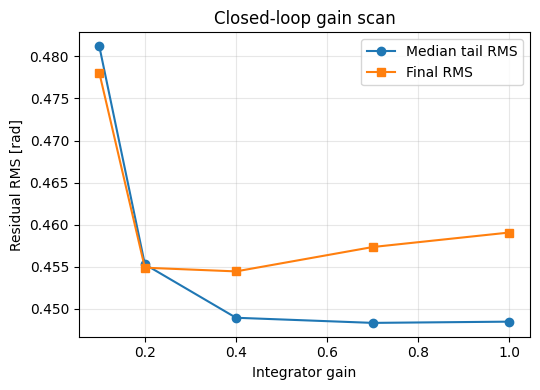

In [13]:
gain_arr = np.array(list(scan.keys()))
median_tail = np.array([scan[g]["median_tail_rms"] for g in gain_arr])
final_rms = np.array([scan[g]["final_rms"] for g in gain_arr])

plt.figure(figsize=(5.5, 4))
plt.plot(gain_arr, median_tail, marker="o", label="Median tail RMS")
plt.plot(gain_arr, final_rms, marker="s", label="Final RMS")
plt.xlabel("Integrator gain")
plt.ylabel("Residual RMS [rad]")
plt.title("Closed-loop gain scan")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 7. Interpretation and next extensions

This notebook turns the project into a genuine AO feedback simulation.  It demonstrates:

1. **DM fitting error:** the actuator grid can only correct spatial frequencies represented by its influence functions.
2. **Closed-loop convergence:** residual RMS decreases after WFS-driven DM updates.
3. **Strehl improvement:** pupil-plane phase correction translates into focal-plane image-quality improvement.
4. **Control tuning:** loop gain changes convergence and residual behavior.

Remaining simplifications:

- The atmosphere is shifted by a toy periodic frozen-flow model rather than a large translated phase screen.
- The WFS is geometric here; it can be replaced by the detector-level centroiding model from notebook 06.
- There is no explicit frame delay, DM dynamics, saturation, or temporal power-spectrum analysis.
- The DM influence functions are simple Gaussians rather than measured/calibrated actuator influence functions.

Good next step: combine notebook 06 and 07 into a **detector-level closed-loop AO simulation** where centroid noise directly drives the control loop.
